In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
sns.set(style="whitegrid")

In [4]:
df = pd.read_excel("student_dataset.xlsx")

In [5]:
df.head()

,student_id,age,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,label
0,STU00001,26,2024-01-13,0,3,5,0.3571,5.29,10,5,0
1,STU00002,23,2024-05-05,0,6,0,0.0000,0.84,7,0,1
2,STU00003,17,2024-03-12,0,3,1,0.0435,1.79,36,0,1
3,STU00004,23,2024-12-12,0,6,13,0.4396,0.78,9,0,1
4,STU00005,20,2024-02-14,0,5,5,0.2078,0.92,11,0,1


In [6]:
df.describe()

,age,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,label
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000
mean,23.736600,0.094000,3.999400,5.188400,0.260985,3.453820,9.3564,4.212200,0.659200
std,4.583211,0.291858,1.997348,6.109466,0.249010,3.248316,9.4361,4.270131,0.474026
min,17.000000,0.000000,1.000000,0.000000,0.000000,0.100000,1.0000,0.000000,0.000000
25%,20.000000,0.000000,2.000000,1.000000,0.053900,0.980000,2.0000,1.000000,0.000000
50%,24.000000,0.000000,4.000000,3.000000,0.206700,2.440000,6.0000,3.000000,1.000000
75%,27.000000,0.000000,6.000000,7.000000,0.389025,4.942500,13.0000,6.000000,1.000000
max,40.000000,1.000000,7.000000,35.000000,1.000000,14.000000,70.0000,24.000000,1.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   enroll_date             5000 non-null   str    
 3   exam_season             5000 non-null   int64  
 4   courses_enrolled        5000 non-null   int64  
 5   completed_assignments   5000 non-null   int64  
 6   completion_rate         5000 non-null   float64
 7   login_frequency         5000 non-null   float64
 8   last_activity_days_ago  5000 non-null   int64  
 9   forum_posts_count       5000 non-null   int64  
 10  label                   5000 non-null   int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 517.7 KB


In [8]:
df["enroll_date"]= pd.to_datetime(df["enroll_date"])

In [10]:
df["enroll_month"]= pd.to_datetime(df["enroll_date"]).dt.month
df["enroll_dayofweek"]=pd.to_datetime(df["enroll_date"]).dt.dayofweek


In [11]:
df

,student_id,age,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,label,enroll_month,enroll_dayofweek
0,STU00001,26,2024-01-13,0,3,5,0.3571,5.29,10,5,0,1,5
1,STU00002,23,2024-05-05,0,6,0,0.0000,0.84,7,0,1,5,6
2,STU00003,17,2024-03-12,0,3,1,0.0435,1.79,36,0,1,3,1
3,STU00004,23,2024-12-12,0,6,13,0.4396,0.78,9,0,1,12,3
4,STU00005,20,2024-02-14,0,5,5,0.2078,0.92,11,0,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,STU04996,26,2024-07-10,0,2,7,0.6537,11.06,1,14,0,7,2
4996,STU04997,34,2024-09-22,0,2,3,0.2559,5.16,15,3,1,9,6
4997,STU04998,18,2024-04-01,0,3,3,0.2242,5.05,5,6,0,4,0
4998,STU04999,24,2024-12-30,0,1,1,0.2659,4.04,1,4,0,12,0


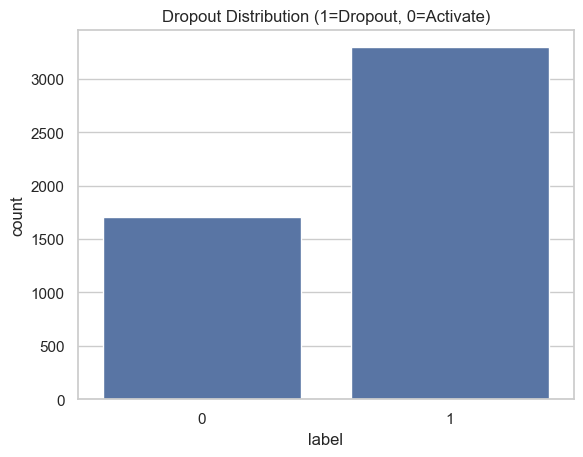

In [12]:
sns.countplot(x="label", data= df)
plt.title("Dropout Distribution (1=Dropout, 0=Activate)")
plt.show()

In [15]:
df["label"].value_counts(normalize=True*100)

label
1    0.6592
0    0.3408
Name: proportion, dtype: float64

In [20]:
num_cols= ["age", "courses_enrolled", "completed_assignments", "completion_rate", "last_activity_days_ago", "forum_posts_count"]

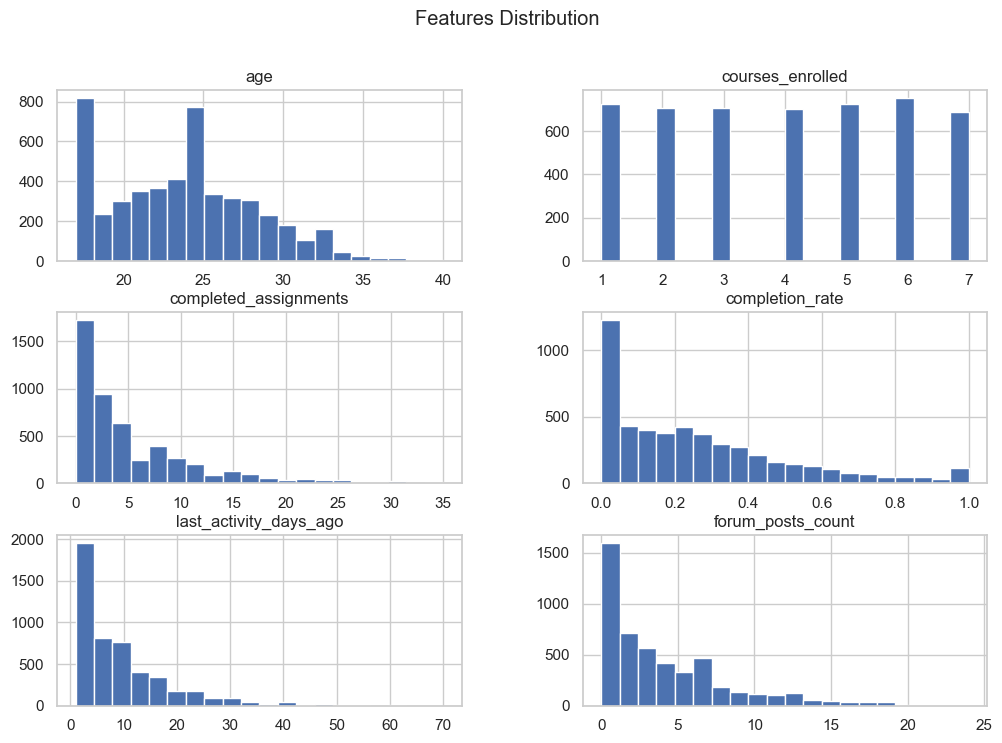

In [28]:
df[num_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Features Distribution")
plt.show()

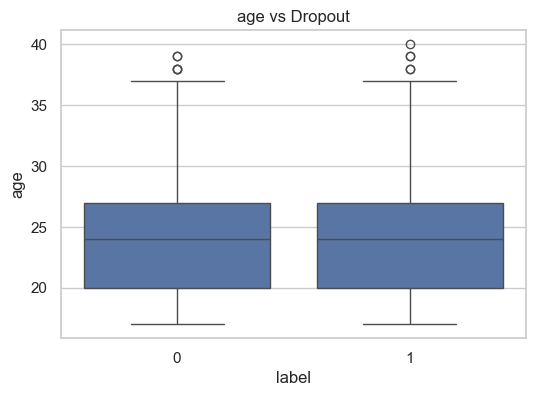

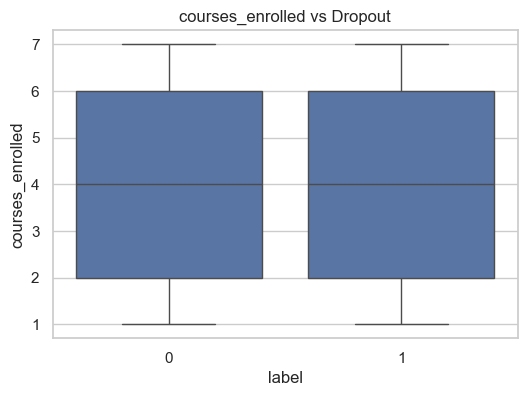

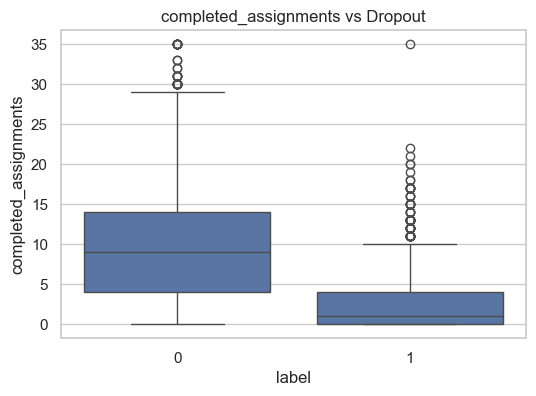

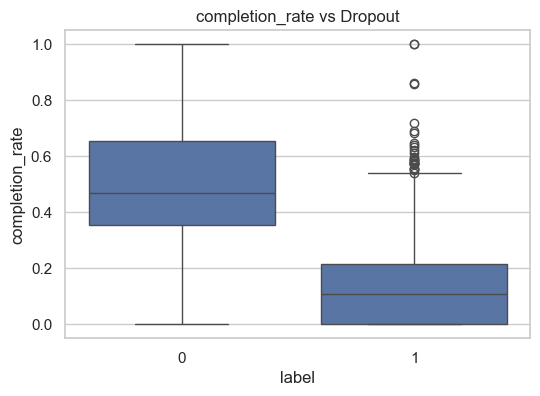

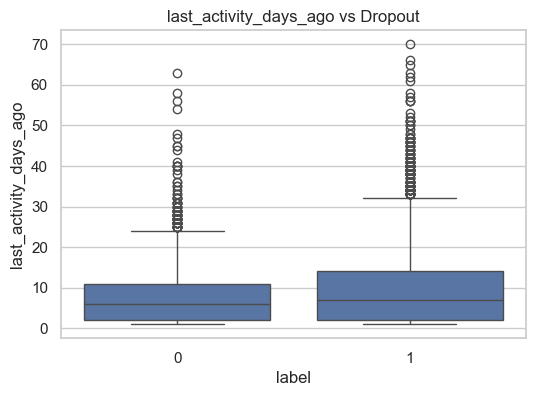

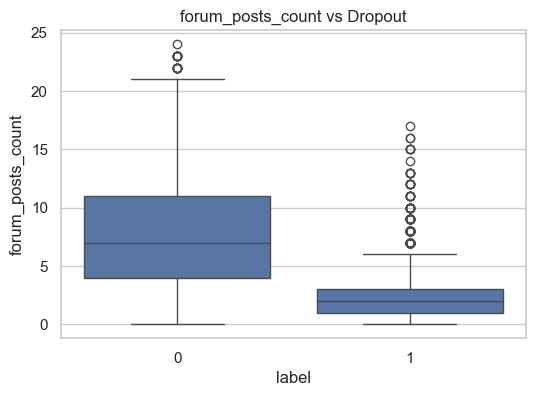

In [30]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="label", y=col, data=df)
    plt.title(f"{col} vs Dropout")
    plt.show()

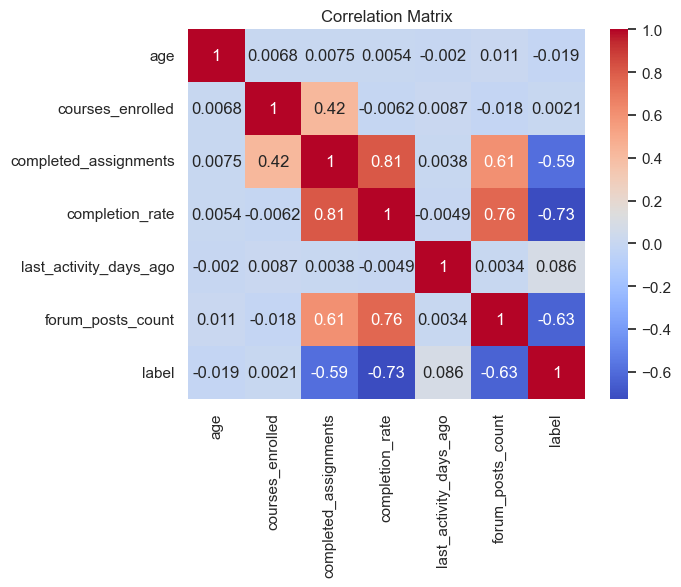

In [32]:
plt.Figure(figsize=(10,6))
sns.heatmap(df[num_cols+["label"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [34]:
grouped = df.groupby("label")[num_cols].mean()
grouped

,age,courses_enrolled,completed_assignments,completion_rate,last_activity_days_ago,forum_posts_count
label,,,,,,
0,23.856808,3.993545,10.214789,0.512990,8.231808,7.980634
1,23.674454,4.002427,2.589806,0.130701,9.937803,2.263956


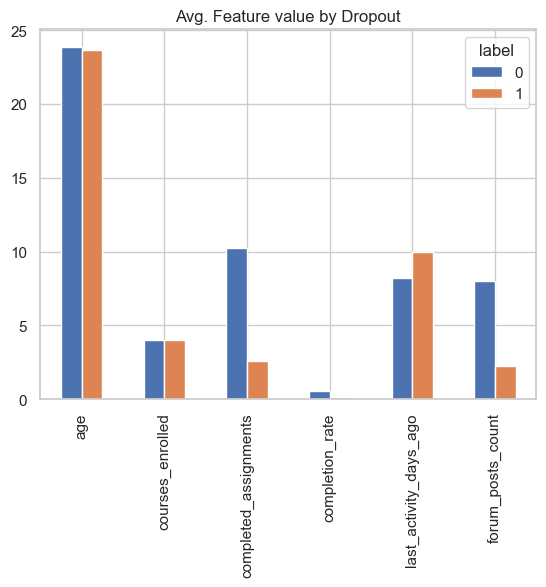

In [37]:
grouped.T.plot(kind="bar", title= "Avg. Feature value by Dropout")
plt.show()

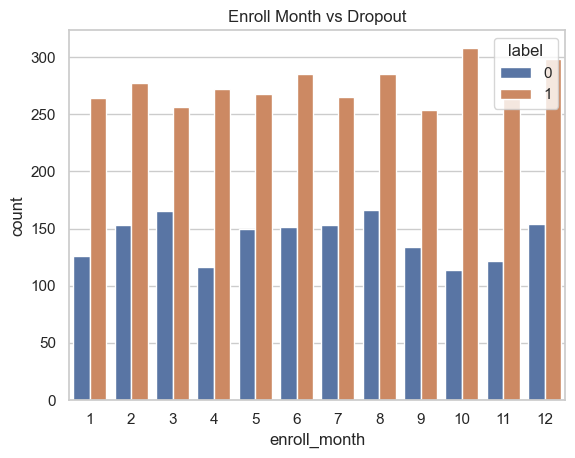

In [38]:
sns.countplot(x="enroll_month", hue="label", data=df)
plt.title("Enroll Month vs Dropout")
plt.show()

In [39]:
df.head(2)

,student_id,age,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,label,enroll_month,enroll_dayofweek
0,STU00001,26,2024-01-13,0,3,5,0.3571,5.29,10,5,0,1,5
1,STU00002,23,2024-05-05,0,6,0,0.0000,0.84,7,0,1,5,6


In [42]:
df["engagment_score"]= (df["login_frequency"]*0.4 + df["completion_rate"]*0.4 + df["forum_posts_count"]*0.2)

In [43]:
df["engagment_score"]

0       3.25884
1       0.33600
2       0.73340
3       0.48784
4       0.45112
         ...   
4995    7.48548
4996    2.76636
4997    3.30968
4998    2.52236
4999    2.00164
Name: engagment_score, Length: 5000, dtype: float64

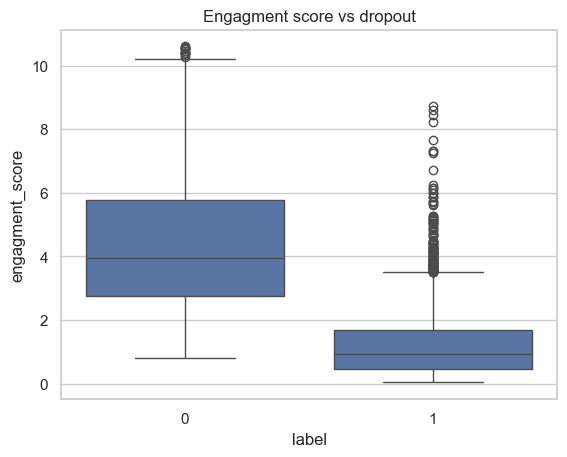

In [47]:
sns.boxplot(x="label", y="engagment_score", data=df)
plt.title("Engagment score vs dropout")
plt.show()

In [48]:
df.columns

Index(['student_id', 'age', 'enroll_date', 'exam_season', 'courses_enrolled',
       'completed_assignments', 'completion_rate', 'login_frequency',
       'last_activity_days_ago', 'forum_posts_count', 'label', 'enroll_month',
       'enroll_dayofweek', 'engagment_score'],
      dtype='str')

In [52]:
features= [
    "completion_rate", "login_frequency","last_activity_days_ago", "courses_enrolled", "forum_posts_count"
]

In [53]:
X= df[features]

In [54]:
X

,completion_rate,login_frequency,last_activity_days_ago,courses_enrolled,forum_posts_count
0,0.3571,5.29,10,3,5
1,0.0000,0.84,7,6,0
2,0.0435,1.79,36,3,0
3,0.4396,0.78,9,6,0
4,0.2078,0.92,11,5,0
...,...,...,...,...,...
4995,0.6537,11.06,1,2,14
4996,0.2559,5.16,15,2,3
4997,0.2242,5.05,5,3,6
4998,0.2659,4.04,1,1,4


In [55]:
y=df["label"]

In [56]:
y

0       0
1       1
2       1
3       1
4       1
       ..
4995    0
4996    1
4997    0
4998    0
4999    0
Name: label, Length: 5000, dtype: int64

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify= y)



In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf= RandomForestClassifier()

In [59]:
rf_params={
    'n_estimators': [100,200],
    'max_depth': [4, 6 ,8],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2]
}

In [60]:
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='accuracy', n_jobs=-1)

In [61]:
rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [4, 6, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [67]:
best_rf= rf_grid.best_estimator_
print(f"Best RF params: {rf_grid.best_params_}")

Best RF params: {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [69]:
from xgboost import XGBClassifier

In [70]:
xgb= XGBClassifier(
    eval_metric= "logloss",
    use_label_encoder= False
)

In [71]:
xgb_params= {
    "n_estimators":[100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.05, 0.1],
    "subsample":[0.8,1]
}

In [72]:
xgb_grid=GridSearchCV(xgb, xgb_params, cv=3, scoring="accuracy", n_jobs=-1)

In [73]:
xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], 'subsample': [0.8, 1]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [75]:
best_xgb = xgb_grid.best_estimator_
print("Best XGB Params", xgb_grid.best_params_)

Best XGB Params {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}


In [76]:
from sklearn.metrics import accuracy_score

In [77]:
def evaluate_model(model, X_test, y_test, name):
    preds= model.predict(X_test)
    print(f"{name}, Results")
    print("Accuracy", accuracy_score(y_test, preds))

In [78]:
evaluate_model(best_rf, X_test, y_test, "Random Forest")
evaluate_model(best_xgb, X_test, y_test, "XGBoost")

Random Forest, Results
Accuracy 0.923
XGBoost, Results
Accuracy 0.916


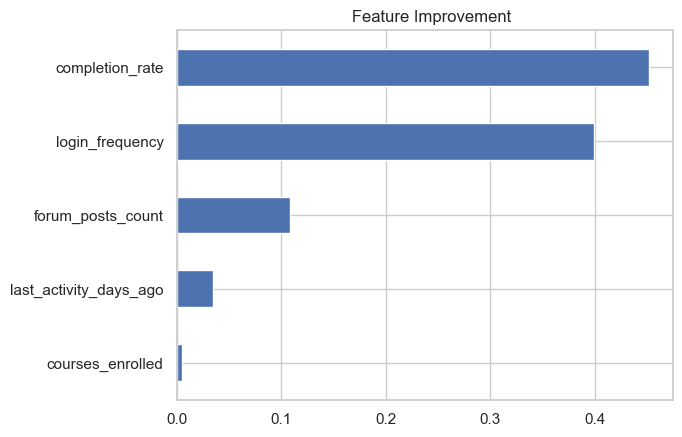

In [82]:
rf_importance= pd.Series(best_rf.feature_importances_, index= features)
rf_importance.sort_values().plot(kind="barh", title= "   Feature Improvement")
plt.show()

In [83]:
import joblib

In [84]:
best_model = best_rf

In [85]:
joblib.dump(best_model, "student_dropout_model.pkl")

['student_dropout_model.pkl']

In [86]:
joblib.dump(features, "model_features.pkl")

['model_features.pkl']